# Example: solving the forward problem

Solving the 2D wave equation using ODIL on a grid $\hat{u}$ involves minimising the functional 

$$\mathcal{L}(\hat{u}) =
    \sum_{(i,\, n) \in \Omega} 
    \left( 
        \frac{\partial^2 \hat{u}}{\partial t^2} -  c^2\nabla^2\hat{u} - f
    \right)^2 
    + \sum_{(i,\, n) \in \Gamma} 
        \left(
            \hat{u} - \hat{g}
        \right)^2,
$$

where $f$ is a source term, and $g$ are the discretised boundary/ initial conditions.

In this example, we will solve an example for which $x = \Delta x i,\, i = 0, 1, 2, \cdots, I$, $y = \Delta y j,\, j = 0, 1, 2, \cdots, J$ for which $I = J = 125$. Let's do so over a domain $x, y \in [0.0, 1.0]$.

We can represent this domain using a `Grid` object:

In [2]:
from odil_wave import Grid
grid = Grid(interior_shape=(30, 30), interior_extent=((0.0, 1.0), (0.0, 1.0)))

Let's take a look at what parameters this grid represents:

In [3]:
print(grid.summary)

Grid interior 30x30 -> total 50x50 (PML p=10),
nt=147, dx=0.0345m, dy=0.0345m,
dt=0.0129 s, cfl@c_ref=0.795,
interior x in [0.00, 1.00]m,
y in [0.00, 1.00]m,
total x in [-0.34, 1.34]m,
total y in [-0.34, 1.34]m


The time discretisation is computed automatically from the spatial spec according to the CFL condition.

The `Grid` class also computes PML boundary absorpiton profiles and bounds the grid with additional nodes to enforce them. Let's look at this more.

<Axes: title={'center': 'PML absorption $\\sigma_x + \\sigma_y$'}, xlabel='x [m]', ylabel='y [m]'>

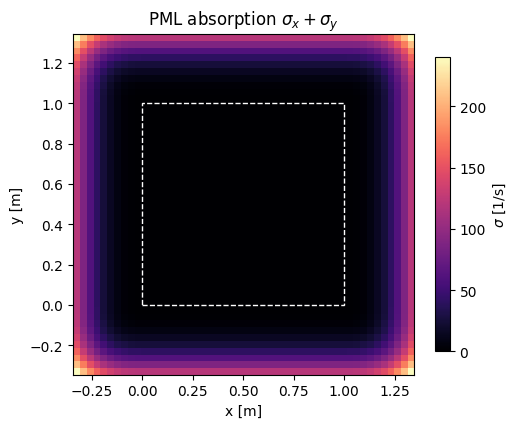

In [4]:
grid.plot_absorption_profile()

From a `Grid`, we can start to build the other components of the problem. First, let's build a velocity model.

<Axes: title={'center': 'c(x, y) [Circular Anomaly Model]'}, xlabel='x [m]', ylabel='y [m]'>

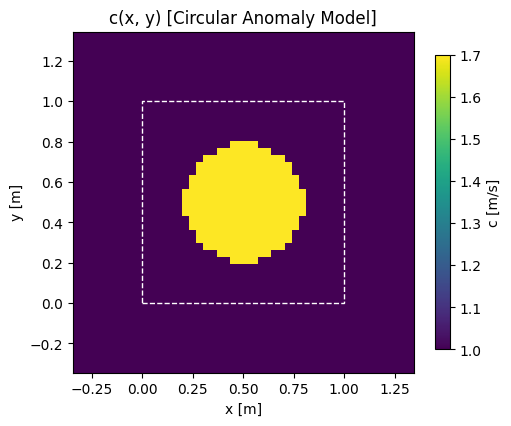

In [5]:
from odil_wave import OverDensityModel

model = OverDensityModel(grid=grid, centre=(0.5, 0.5))
model.show()

Amplitude data can be represented by a `Wavefield` object:

In [6]:
from odil_wave import Wavefield
wavefield = Wavefield(grid=grid)

Our data have 2 spatial dimensions and 1 temporal dimension, so to visualise them we must choose a plane and a slice index:

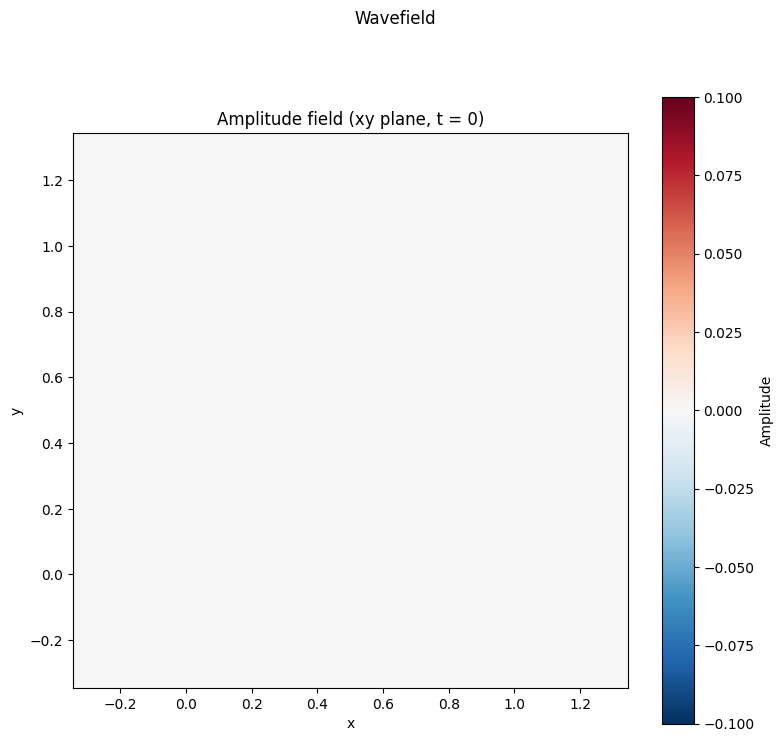

In [7]:
fig = wavefield.show(idx=0)

Amplitude data is initialised to zero by default.

To drive wave propagation, we need a source term. This can be provided by an `AcquisitionGeometry`, which also places receivers on the domain for if we want to include a data loss term (to drive an inverse solve). Since this package is aimed at modelling waves in the brain, sources and receivers are placed in a ring by default, so we must specify the ring center alongside the number of sources and receivers and peak frequency.

In [8]:
from odil_wave import AcquisitionGeometry
geometry = AcquisitionGeometry(grid=grid, n_sources=1, n_receivers=10, ring_center=(0.5, 0.5), a_frac=0.8, b_frac=0.8, f0=3.0)

<Axes: title={'center': 'Acquisition on Circular Anomaly Model'}, xlabel='x [m]', ylabel='y [m]'>

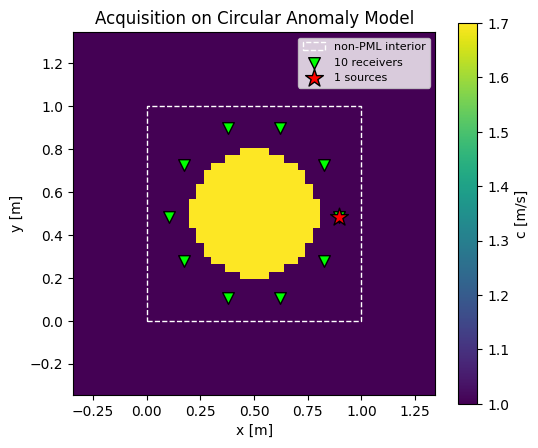

In [9]:
geometry.show(model)

We can now move towards the physics of our problem. The discretisation scheme is controlled by operators of type `Operator` and there are a few options, but thankfully we can just specify the desired method order in time and space to a `WaveEquation` object and it will construct our operators along with objects that apply initial and boundary conditions. 

In [10]:
from odil_wave import WaveEquation
wave_eq = WaveEquation(wavefield, model, time_order=2, space_order=2)

To form a loss function, we can use a `ForwardLoss` object that should be configured by defining our `Problem`.

In [11]:
from odil_wave import Problem
problem = Problem(wave_eq=wave_eq, geometry=geometry)

In [12]:
from odil_wave import ForwardLoss
loss = ForwardLoss(problem=problem)

Our `loss` keeps a `LossTape` that we can use to investigate the loss history after optimisation. First, let's define an optimiser. The optimiser type and various parameters can be configured by using a `ScipyOptimiser` object, but we will just use teh convenience class `LBFGSB`. 

In [14]:
from odil_wave import LBFGSB
optimiser = LBFGSB(loss)

First, let's look at what the intial loss and gradient looks like:

In [17]:
import numpy as np

loss_val, grad = loss.evaluate(wavefield.U)
print("loss:", loss_val)
print("grad norm:", np.linalg.norm(grad))
print("grad max:", np.abs(grad).max())

loss: 27.29464729526763
grad norm: 7376.886717722498
grad max: 1360.2126401478827


Finally, we can run the optimisation.

In [24]:
wavefield, tape = optimiser.minimise(maxiter=1000, ftol=1e-6, gtol=1e-8)

In [25]:
tape.result

  message: STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT
  success: False
   status: 1
      fun: 0.02967359011104547
        x: [ 8.899e-09  3.253e-08 ... -1.562e-09  1.114e-10]
      nit: 1000
      jac: [-1.690e-04 -5.345e-04 ...  1.549e-01  7.382e-02]
     nfev: 1030
     njev: 1030
 hess_inv: <367500x367500 LbfgsInvHessProduct with dtype=float64>

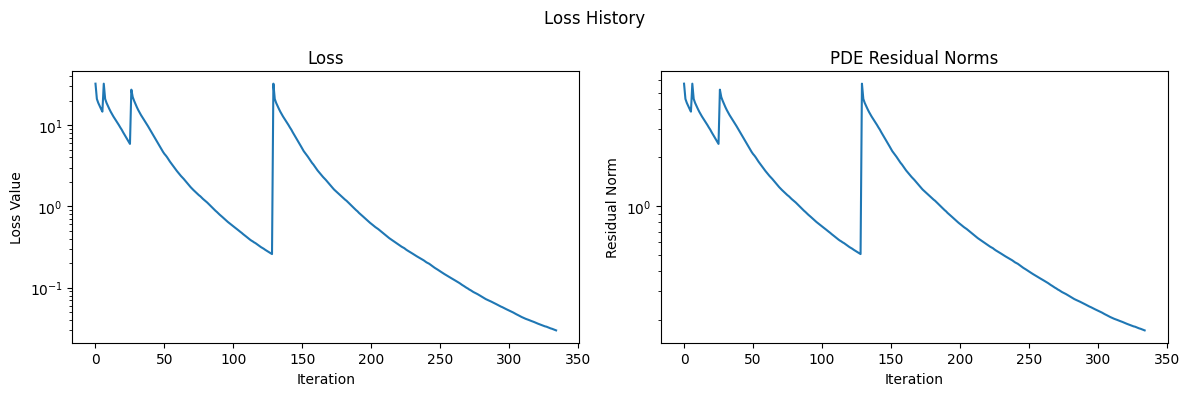

In [26]:
tape.show()

In [27]:
outfile = wavefield.animate()

While iterative methods can produce a decent result, we can also use a Gauss-Newton method:

In [13]:
from odil_wave.optimisation import GaussNewtonOptimiser
optimiser = GaussNewtonOptimiser(loss, outer_maxiter=100)

In [14]:
result, tape = optimiser.minimise(wavefield, method="cg", inner_maxiter=100) # inner solve JTJ du = -JT r using cg

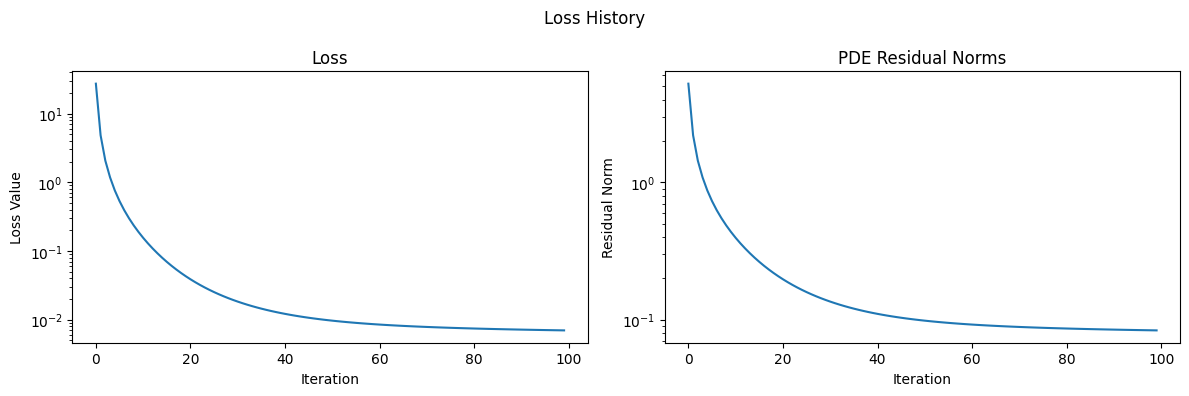

In [15]:
tape.show()

In [16]:
outfile = result.animate()